# CSO — análise de sensibilidade

Este notebook explora os resultados persistidos por `run_sensitivity.py`. Ele não executa o CSO novamente.

A métrica principal é o **normalized performance gap**: 0 representa o melhor desempenho observado no cenário e 1 o pior. O valor é calculado separadamente para cada combinação de problema e dimensão, evitando misturar escalas diferentes entre funções de benchmark.


In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from experiment_artifacts import ExperimentArtifactStore
from run_validation import create_validation_experiment
from sensitivity_analysis import (
    analyze_sensitivity,
    create_configuration_comparison_table,
    create_parameter_effect_table,
)

ARTIFACT_ROOT = Path("_artifacts")
experiment = create_validation_experiment()
artifact_store = ExperimentArtifactStore(ARTIFACT_ROOT, experiment)
sensitivity = analyze_sensitivity(artifact_store, experiment)
configuration_table = create_configuration_comparison_table(sensitivity)
parameter_table = sensitivity.parameter_table.copy()
scenario_table = sensitivity.scenario_table.copy()

print(f"Experiment ID: {sensitivity.experiment_id}")
print(f"Configurations: {sensitivity.configuration_count}")
print(f"Scenarios: {sensitivity.scenario_count}")
print(
    f"Runs analyzed: {sensitivity.analyzed_run_count}/{sensitivity.validation_report.expected_run_count}"
)

Experiment ID: experiment_db477ccd2067bc14
Configurations: 9
Scenarios: 6
Runs analyzed: 162/162


## Validação


In [8]:
validation = sensitivity.validation_report
pd.Series(
    {
        "valid": validation.is_valid,
        "expected_runs": validation.expected_run_count,
        "completed_runs": validation.completed_run_count,
        "missing_runs": len(validation.missing_run_ids),
        "invalid_runs": validation.invalid_run_count,
        "errors": validation.error_count,
        "warnings": validation.warning_count,
    }
)

valid             True
expected_runs      162
completed_runs     162
missing_runs         0
invalid_runs         0
errors               0
warnings             0
dtype: object

## Efeito marginal dos parâmetros

Para cada nível, `mean_normalized_gap` é a média sobre as demais configurações e sobre os cenários. Em um desenho fatorial, isso descreve um efeito marginal e não deve ser tratado como efeito causal quando há interações importantes entre parâmetros.


In [9]:
parameter_effect_summary = create_parameter_effect_table(sensitivity)
parameter_effect_summary

,parameter,level_count,minimum_mean_normalized_gap,maximum_mean_normalized_gap,effect_range
0,c1,3,0.139176,0.227639,0.088463
1,mixture_ratio,3,0.017094,0.450983,0.433889


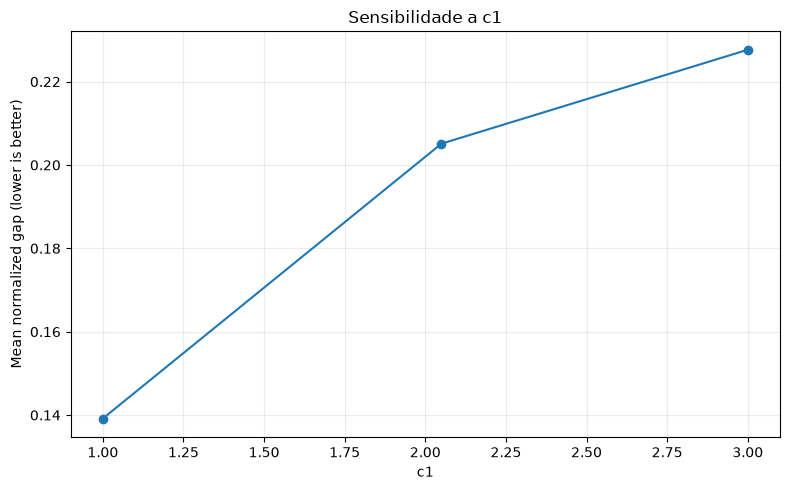

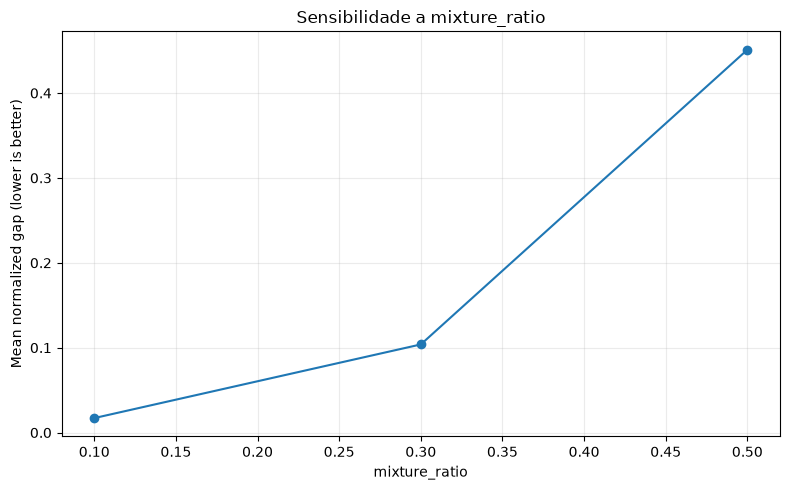

In [10]:
for parameter_name in sensitivity.parameter_names:
    parameter_effect = sensitivity.parameter_effect(parameter_name)
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.plot(
        parameter_effect["parameter_value"],
        parameter_effect["mean_normalized_gap"],
        marker="o",
    )
    axis.set_title(f"Sensibilidade a {parameter_name}")
    axis.set_xlabel(parameter_name)
    axis.set_ylabel("Mean normalized gap (lower is better)")
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    plt.show()

## Comparação das configurações


In [11]:
configuration_table

,configuration_id,algorithm,c1,mixture_ratio,scenario_count,mean_normalized_gap,std_normalized_gap,mean_rank,worst_normalized_gap
0,configuration_0f10cfd09176c52c,CatSwarmOptimization,1.00,0.1,6,1.538137e-38,3.767650e-38,3.000000,9.228819e-38
1,configuration_c1fbbfcef8f00dd2,CatSwarmOptimization,3.00,0.1,6,1.819306e-02,4.456371e-02,2.833333,1.091584e-01
2,configuration_0c2f09b3584d2928,CatSwarmOptimization,2.05,0.1,6,3.309024e-02,8.105421e-02,3.166667,1.985415e-01
3,configuration_ecf78e4c2a564c5d,CatSwarmOptimization,1.00,0.3,6,9.764573e-02,2.391753e-01,4.666667,5.858603e-01
4,configuration_4d15276a95f0c203,CatSwarmOptimization,2.05,0.3,6,1.067922e-01,2.536243e-01,5.333333,6.243939e-01
5,configuration_a7a46233160671d3,CatSwarmOptimization,3.00,0.3,6,1.070985e-01,2.599307e-01,5.000000,6.376716e-01
6,configuration_fa71f4fea78fa3d1,CatSwarmOptimization,1.00,0.5,6,3.198827e-01,4.585576e-01,6.833333,1.000000e+00
7,configuration_e7fd8f366d42126d,CatSwarmOptimization,2.05,0.5,6,4.754418e-01,4.000637e-01,6.833333,1.000000e+00
8,configuration_e04e5c05e89c915f,CatSwarmOptimization,3.00,0.5,6,5.576246e-01,4.658199e-01,7.333333,1.000000e+00


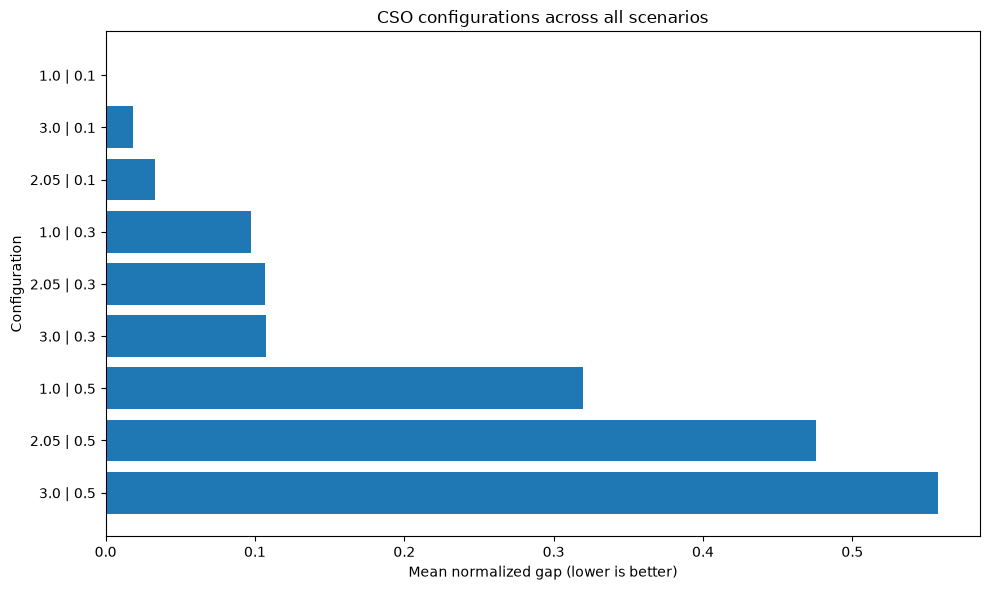

In [12]:
figure, axis = plt.subplots(figsize=(10, 6))
plot_table = configuration_table.copy()
parameter_columns = list(sensitivity.parameter_names)
plot_table["label"] = [
    " | ".join(map(str, values))
    for values in plot_table.loc[:, parameter_columns].itertuples(
        index=False, name=None
    )
]
plot_table = plot_table.sort_values("mean_normalized_gap")
axis.barh(plot_table["label"], plot_table["mean_normalized_gap"])
axis.invert_yaxis()
axis.set_xlabel("Mean normalized gap (lower is better)")
axis.set_ylabel("Configuration")
axis.set_title("CSO configurations across all scenarios")
figure.tight_layout()
plt.show()


## Interação entre `c1` e `mixture_ratio`

Quando há exatamente esses dois parâmetros no grid, o heatmap mostra a média do normalized gap para cada combinação.


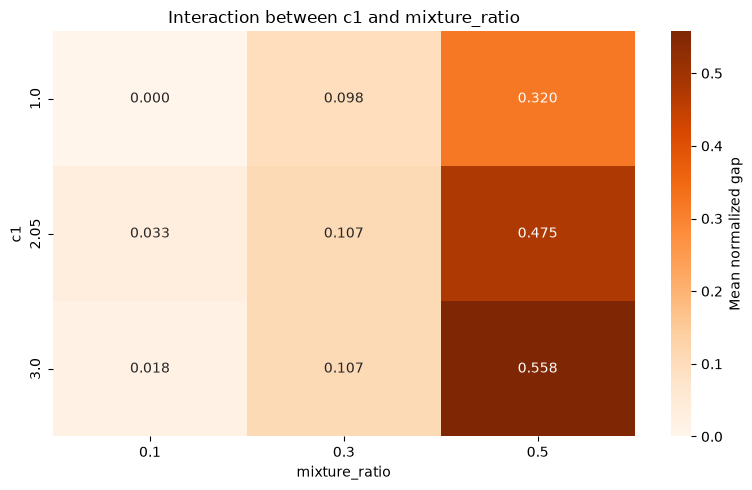

In [13]:
required_parameters = {"c1", "mixture_ratio"}
if required_parameters.issubset(sensitivity.parameter_names):
    heatmap_data = configuration_table.pivot(
        index="c1",
        columns="mixture_ratio",
        values="mean_normalized_gap",
    )
    figure, axis = plt.subplots(figsize=(8, 5))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="Oranges",
        cbar_kws={"label": "Mean normalized gap"},
        ax=axis,
    )
    axis.set_title("Interaction between c1 and mixture_ratio")
    axis.set_xlabel("mixture_ratio")
    axis.set_ylabel("c1")
    figure.tight_layout()
    plt.show()
else:
    print(
        "The current sensitivity grid does not contain c1 and mixture_ratio together."
    )

## Desempenho por cenário


In [14]:
scenario_table.sort_values(["problem", "dimension", "normalized_gap"])[
    [
        "problem",
        "dimension",
        "configuration_id",
        "normalized_gap",
        "scenario_rank",
        "mean_best_value",
        "std_best_value",
    ]
].head(30)

,problem,dimension,configuration_id,normalized_gap,scenario_rank,mean_best_value,std_best_value
0,Rastrigin,10,configuration_0f10cfd09176c52c,0.000000e+00,1.0,1.227873e+00,2.126738e+00
1,Rastrigin,10,configuration_c1fbbfcef8f00dd2,1.091584e-01,2.0,6.149157e+00,1.065065e+01
2,Rastrigin,10,configuration_0c2f09b3584d2928,1.985415e-01,3.0,1.017890e+01,1.763036e+01
3,Rastrigin,10,configuration_ecf78e4c2a564c5d,5.858603e-01,4.0,2.764074e+01,1.580555e+01
4,Rastrigin,10,configuration_4d15276a95f0c203,6.243939e-01,5.0,2.937798e+01,6.958390e+00
5,Rastrigin,10,configuration_a7a46233160671d3,6.376716e-01,6.0,2.997660e+01,7.931964e+00
6,Rastrigin,10,configuration_e7fd8f366d42126d,6.742791e-01,7.0,3.162701e+01,1.302379e+01
7,Rastrigin,10,configuration_e04e5c05e89c915f,8.230299e-01,8.0,3.833327e+01,8.687787e+00
8,Rastrigin,10,configuration_fa71f4fea78fa3d1,1.000000e+00,9.0,4.631178e+01,1.450315e+00
9,Rastrigin,100,configuration_0c2f09b3584d2928,0.000000e+00,2.0,0.000000e+00,0.000000e+00


## Arquivos exportados

A execução de `run_sensitivity.py` grava as tabelas CSV e os metadados em `_artifacts/<experiment_id>__<slug>/analysis/`. Isso deixa a análise reprodutível e separa os resultados numéricos dos gráficos finais dos slides.
